<a href="https://colab.research.google.com/github/ArlinMarsyanda/Data-Preprocessing/blob/main/Uts_Data_Mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas
import pandas as pd
# Memuat data dari file CSV
df = pd.read_csv('/content/water_potability.csv')
# Menampilkan 5 baris pertama dari dataset
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
!pip install numpy
import numpy as np
# Mengganti "?" dengan NaN
df.replace("?", np.nan, inplace=True)
# Memeriksa jumlah missing values di setiap kolom
print(df.isnull().sum())

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


"""MENGGANTI MISSING VALUE DENGAN MEAN PADA DATA NUMERIK

Alasan mengisi missing data dengan mean, karena kolom tersebut memiliki data yang bersifat kontinu dan bertipe numerik. """

In [ ]:
#Mengganti missing values dengan rata-rata pada kolom numerik
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# Correct column names based on the DataFrame
cols_to_replace = ["ph", "Hardness", "Solids", "Chloramines", "Sulfate"]
# replaced with actual columns from your data

for col in cols_to_replace:
    # Convert the column to numeric, coercing errors to NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')
    avg_value = df[col].mean()
    df[col].replace(np.nan, avg_value, inplace=True)
    print(f"Average of {col}: {avg_value}")

Average of ph: 7.080794504276835
Average of Hardness: 196.36949601730151
Average of Solids: 22014.092526077104
Average of Chloramines: 7.122276793425786
Average of Sulfate: 333.7757766108135


In [ ]:
#Data Normalisasi
#Menampilkan nilai sebelum normalisasi
# Assuming your columns are named 'ph', 'Hardness', and 'Solids'
# Replace these with your desired columns for normalization
print("Max ph:", df['ph'].max())
print("Max Hardness:", df['Hardness'].max())
print("Max Solids:", df['Solids'].max())

# Normalisasi kolom length, width, height
df['ph'] = df['ph'] / df['ph'].max()
df['Hardness'] = df['Hardness'] / df['Hardness'].max()
df['Solids'] = df['Solids'] / df['Solids'].max()

# Menampilkan beberapa baris pertama dari kolom yang dinormalisasi
print(df[['ph', 'Hardness', 'Solids']].head())

Max ph: 13.999999999999998
Max Hardness: 323.124
Max Solids: 61227.19600771213
         ph  Hardness    Solids
0  0.505771  0.634092  0.339577
1  0.265434  0.400536  0.304277
2  0.578509  0.693963  0.325175
3  0.594055  0.663440  0.359618
4  0.649445  0.560471  0.293644


In [ ]:
!pip install matplotlib seaborn

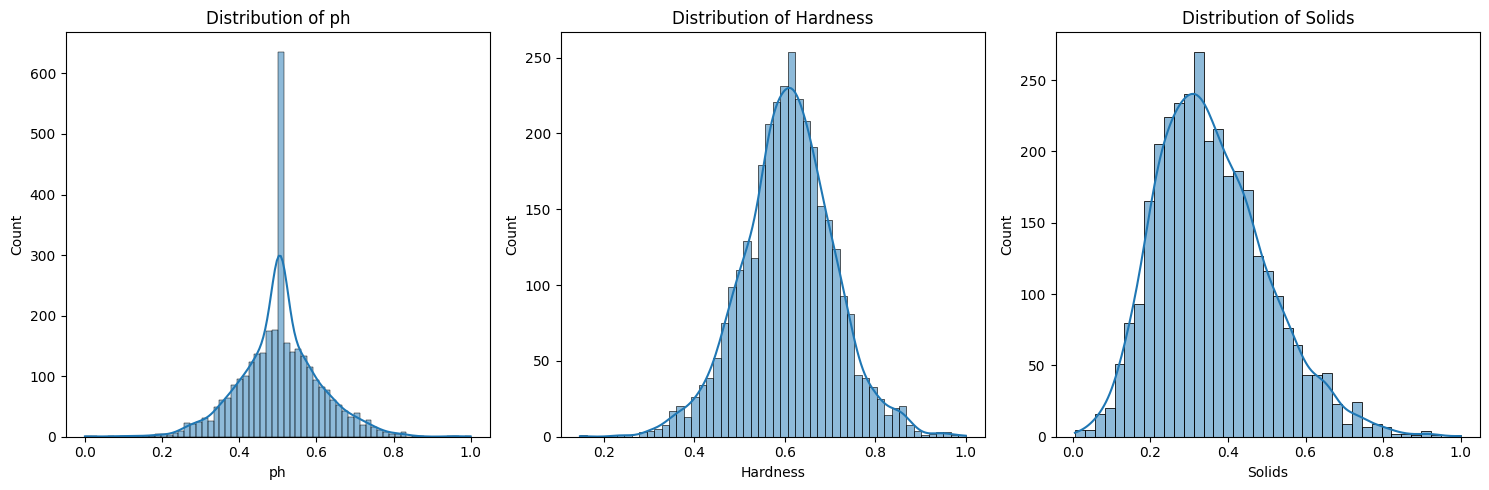

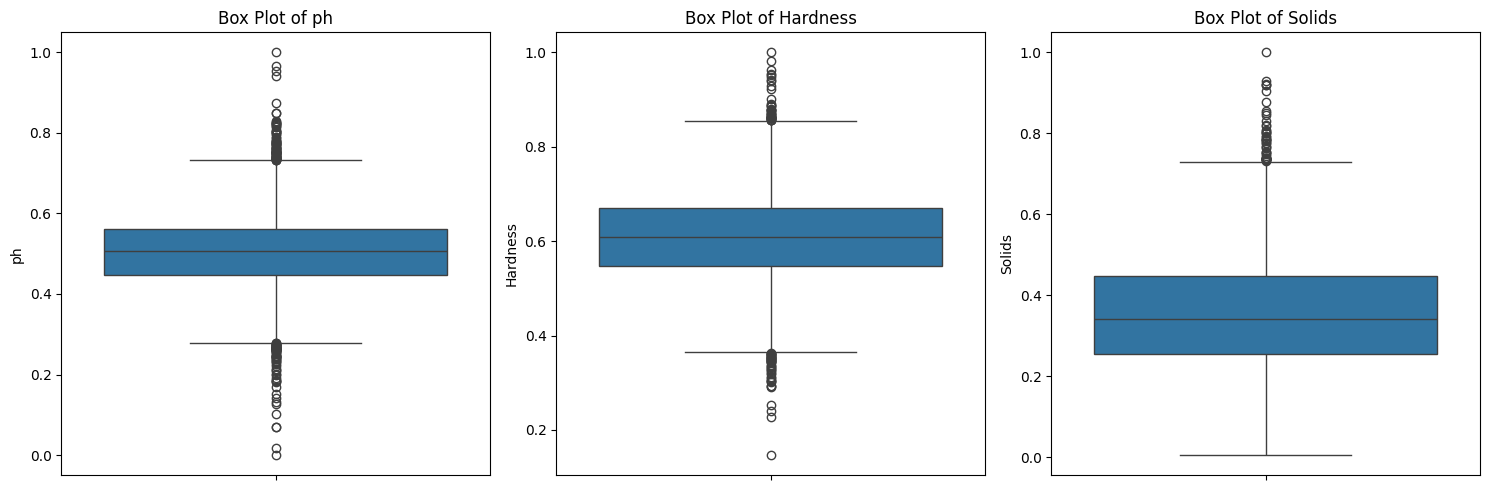

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(df['ph'], ax=axes[0], kde=True)
axes[0].set_title('Distribution of ph')
sns.histplot(df['Hardness'], ax=axes[1], kde=True)
axes[1].set_title('Distribution of Hardness')
sns.histplot(df['Solids'], ax=axes[2], kde=True)
axes[2].set_title('Distribution of Solids')
plt.tight_layout()
plt.show()

# Create box plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=df['ph'], ax=axes[0])
axes[0].set_title('Box Plot of ph')
sns.boxplot(y=df['Hardness'], ax=axes[1])
axes[1].set_title('Box Plot of Hardness')
sns.boxplot(y=df['Solids'], ax=axes[2])
axes[2].set_title('Box Plot of Solids')
plt.tight_layout()
plt.show()

In [ ]:
import os

#Specify a valid directory path.
# If running on Colab, consider using '/content/'
# If running on a remote server, use an appropriate directory path
directory_path = '/content/'  # For Colab, change to your preferred directory
file_name = 'water_potability_cleaned.csv'

# Create the directory if it doesn't exist
os.makedirs(directory_path, exist_ok=True)

# Construct the full file path
file_path = os.path.join(directory_path, file_name)

# Save the DataFrame to the CSV file
df.to_csv(file_path, index=False)

First 5 rows of the data:
         ph  Hardness    Solids  Chloramines     Sulfate  Conductivity  \
0  0.505771  0.634092  0.339577     7.300212  368.516441    564.308654   
1  0.265434  0.400536  0.304277     6.635246  333.775777    592.885359   
2  0.578509  0.693963  0.325175     9.275884  333.775777    418.606213   
3  0.594055  0.663440  0.359618     8.059332  356.886136    363.266516   
4  0.649445  0.560471  0.293644     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  

Dataframe Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  

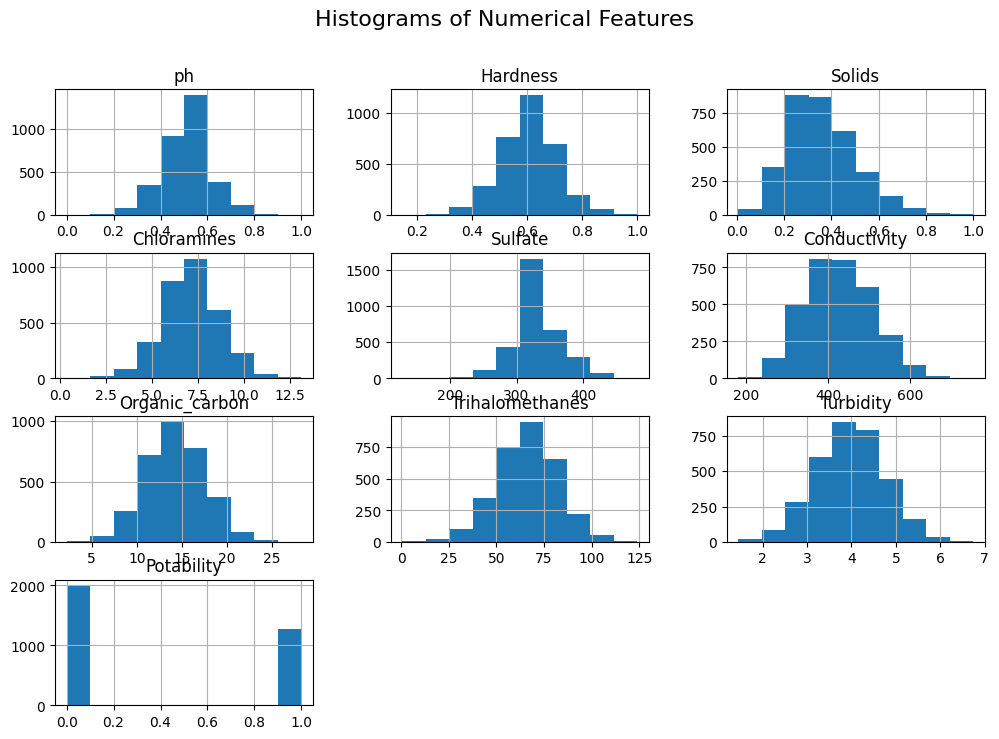

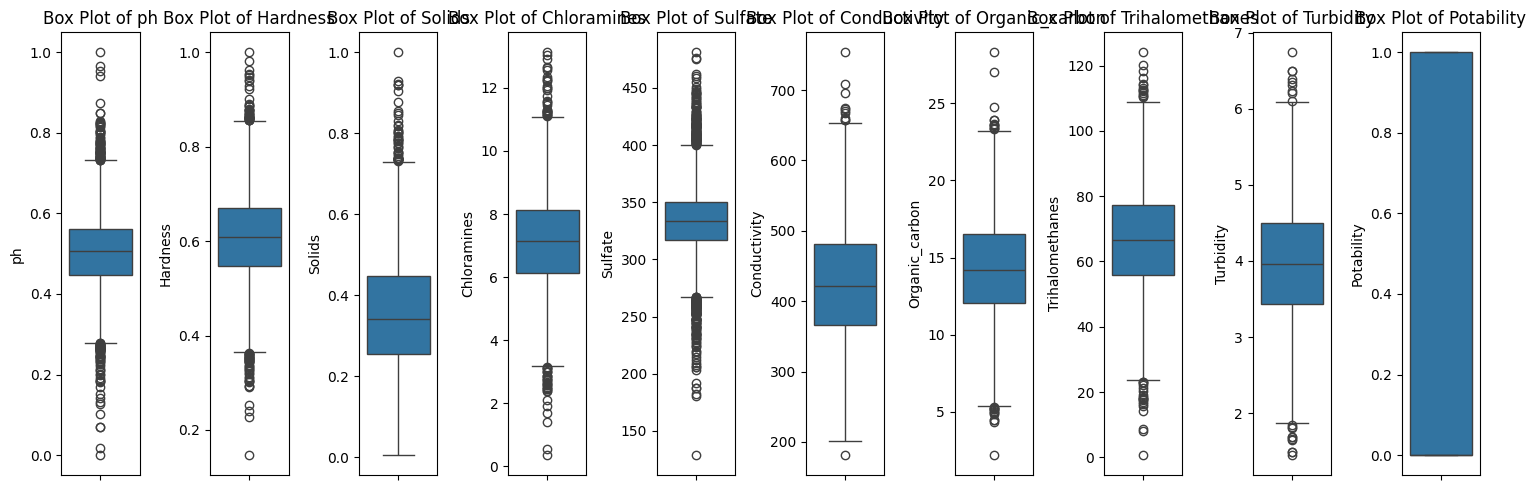

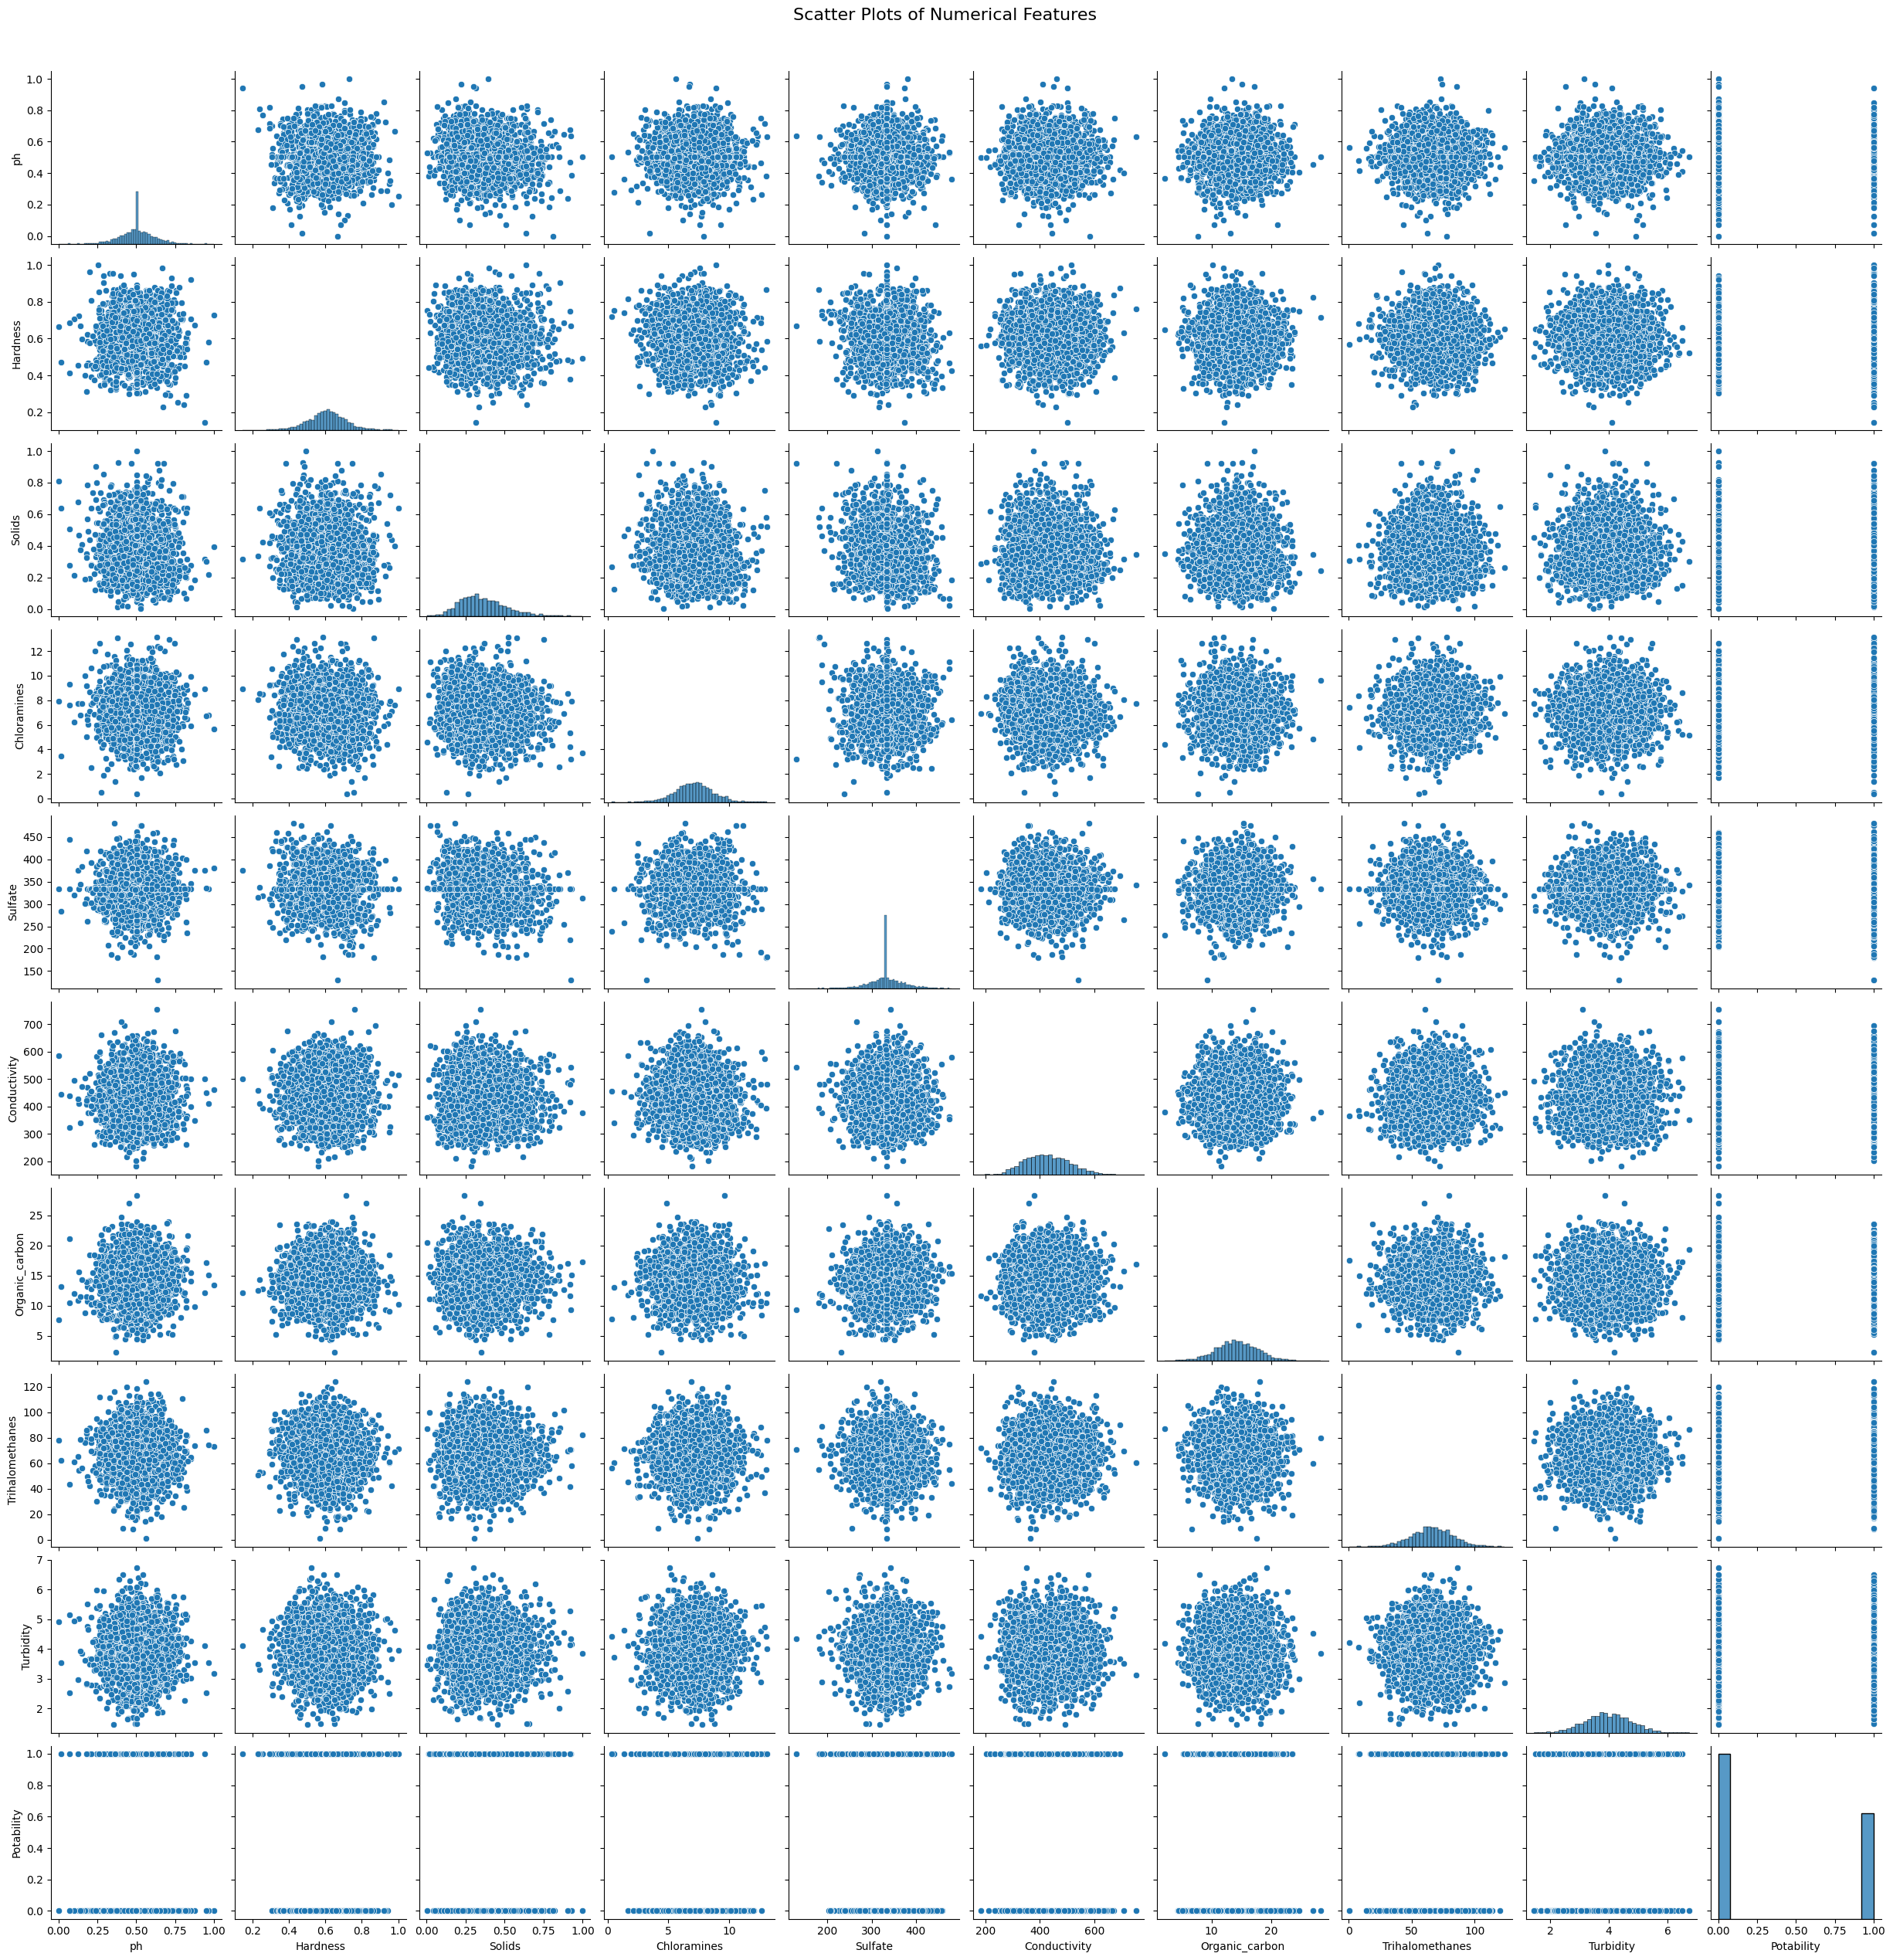

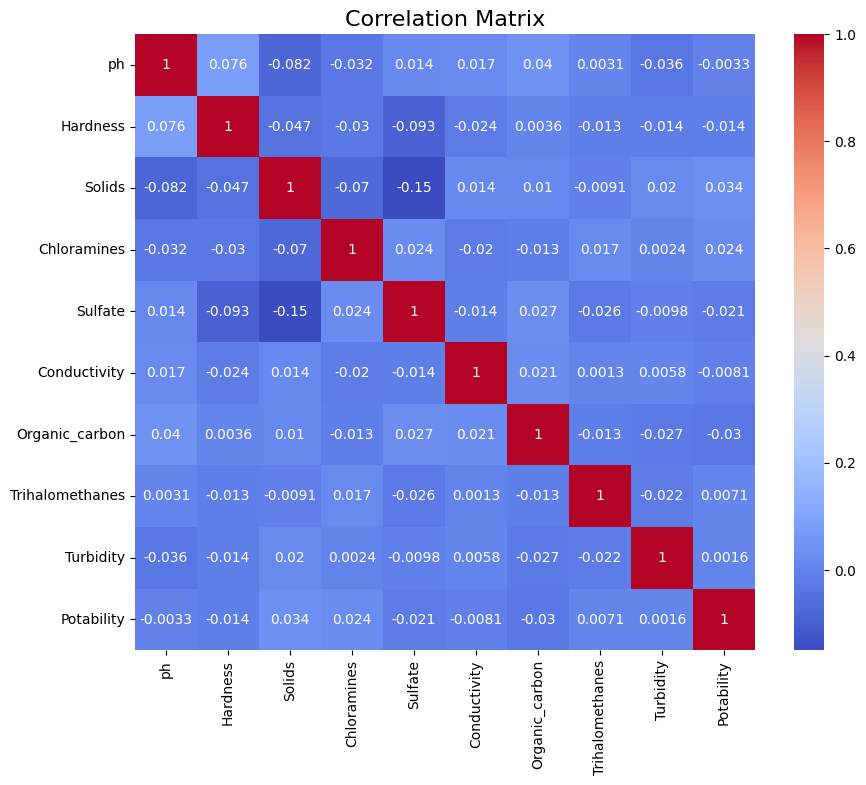


Mean values by Potability:
                  ph  Hardness    Solids  Chloramines     Sulfate  \
Potability                                                          
0           0.506047  0.608848  0.355683     7.092175  334.371700   
1           0.505340  0.605962  0.365589     7.169338  332.844122   

            Conductivity  Organic_carbon  Trihalomethanes  Turbidity  
Potability                                                            
0             426.730454       14.364335        66.303555   3.965800  
1             425.383800       14.160893        66.539684   3.968328  


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your data is loaded in a DataFrame named 'df'
# Replace 'water_potability_cleaned.csv' with your actual file path if needed
file_path = 'water_potability_cleaned.csv'
df = pd.read_csv(file_path)

# 1. Basic Data Exploration
# Display the first few rows of the DataFrame
print("First 5 rows of the data:")
print(df.head())

# Get information about the DataFrame's structure and data types
print("\nDataframe Info:")
print(df.info())

# Get descriptive statistics of numerical columns
print("\nDescriptive Statistics:")
print(df.describe())

# 2. Data Visualization
# Create histograms for numerical features
df.hist(figsize=(12, 8))
plt.suptitle("Histograms of Numerical Features", fontsize=16)
plt.show()

# Create box plots for numerical features
fig, axes = plt.subplots(1, len(df.select_dtypes(include=['number']).columns), figsize=(15, 5))
for i, col in enumerate(df.select_dtypes(include=['number']).columns):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

# Create scatter plots to visualize relationships between features
sns.pairplot(df)
plt.suptitle("Scatter Plots of Numerical Features", fontsize=16, y=1.02)
plt.show()

# 3. Correlation Analysis
# Calculate and visualize the correlation matrix
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix", fontsize=16)
plt.show()

# 4. Further Analysis (Example: Groupby and Aggregation)
# Group data by 'Potability' and calculate the mean of other features
potability_group = df.groupby('Potability').mean()
print("\nMean values by Potability:")
print(potability_group)

# ... Add more analysis steps as needed ...